# Equity Analysis with Python - Introduction (Part 1)

__Please install yfinance__ with the following command (Anaconda Prompt/Terminal Window):

pip install yfinance

## yfinance API - first steps

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [3]:
symbol = "AAPL" # ticker symbol for Apple Inc.

In [4]:
df = yf.download(tickers = symbol, interval = "1d", multi_level_index=False)
df

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2026-02-03,269.228088,271.625839,267.359811,268.948351,64394700
2026-02-04,276.231506,278.689229,272.035451,272.035451,90545700
2026-02-05,275.652069,279.238709,272.974582,277.869995,52977400
2026-02-06,277.859985,280.647386,276.671095,276.860920,50453400
2026-02-09,274.619995,278.200012,271.700012,277.910004,44623400
2026-02-10,273.679993,275.369995,272.940002,274.890015,34376900
2026-02-11,275.500000,280.179993,274.450012,274.700012,51931300
2026-02-12,261.730011,275.720001,260.179993,275.589996,81077200
2026-02-13,255.779999,262.230011,255.449997,262.010010,56290700


In [5]:
df.index = pd.to_datetime(df.index.date)
df

,Close,High,Low,Open,Volume
2026-02-03,269.228088,271.625839,267.359811,268.948351,64394700
2026-02-04,276.231506,278.689229,272.035451,272.035451,90545700
2026-02-05,275.652069,279.238709,272.974582,277.869995,52977400
2026-02-06,277.859985,280.647386,276.671095,276.860920,50453400
2026-02-09,274.619995,278.200012,271.700012,277.910004,44623400
2026-02-10,273.679993,275.369995,272.940002,274.890015,34376900
2026-02-11,275.500000,280.179993,274.450012,274.700012,51931300
2026-02-12,261.730011,275.720001,260.179993,275.589996,81077200
2026-02-13,255.779999,262.230011,255.449997,262.010010,56290700
2026-02-17,263.880005,266.290009,255.539993,258.049988,58469100


In [6]:
df.index

DatetimeIndex(['2026-02-03', '2026-02-04', '2026-02-05', '2026-02-06',
               '2026-02-09', '2026-02-10', '2026-02-11', '2026-02-12',
               '2026-02-13', '2026-02-17', '2026-02-18', '2026-02-19',
               '2026-02-20', '2026-02-23', '2026-02-24', '2026-02-25',
               '2026-02-26', '2026-02-27', '2026-03-02'],
              dtype='datetime64[ns]', freq=None)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19 entries, 2026-02-03 to 2026-03-02
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   19 non-null     float64
 1   High    19 non-null     float64
 2   Low     19 non-null     float64
 3   Open    19 non-null     float64
 4   Volume  19 non-null     int64  
dtypes: float64(4), int64(1)
memory usage: 912.0 bytes


- __Date__: Date (year-month-day) at midnight New York Time (business daily data without weekends and bank holidays)
- __Open__: daily Open Price @ 9:30 am Eastern TimeZone
- __High__: daily high/max price
- __Low__: daily low/min price
- __Close__: daily Close Price @ 4:00 pm Eastern TimeZone
- __Adj Close__: Close price adjusted for Dividend Payments (backward adjusted)
- __Volume__: daily Trading Volume (number of Shares)

__Price Chart__

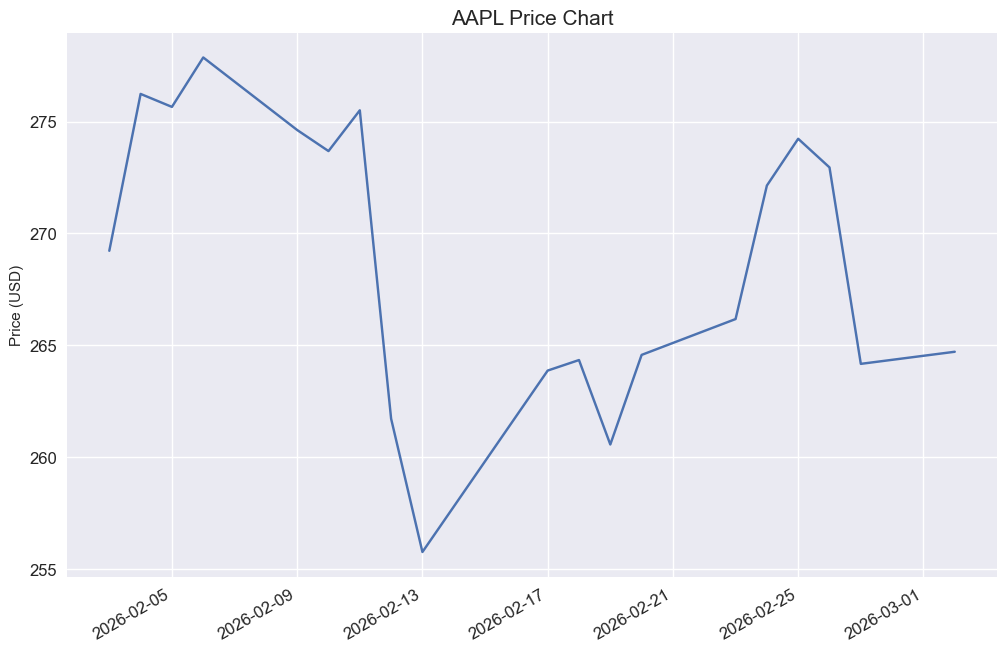

In [8]:
df.Close.plot(figsize = (12, 8), fontsize = 12)
plt.ylabel("Price (USD)")
plt.title("AAPL Price Chart", fontsize = 15)
plt.show()

__Volume Chart__

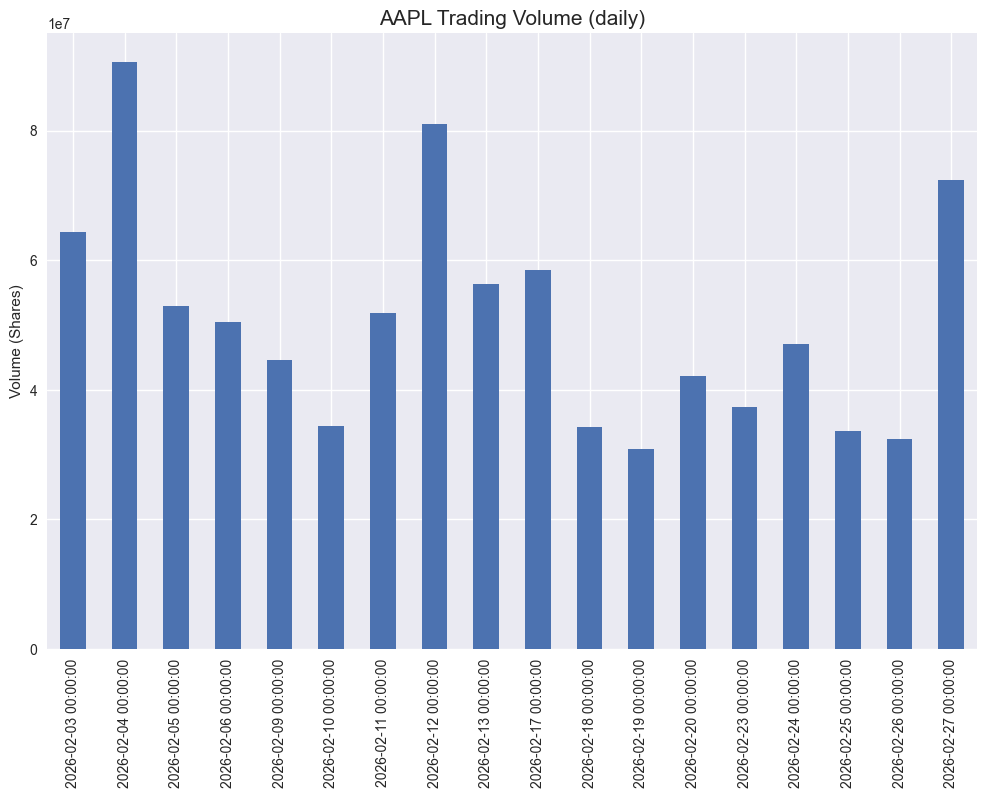

In [9]:
df.loc["2026-02", "Volume"].plot(figsize = (12, 8), kind = "bar")
plt.ylabel("Volume (Shares)")
plt.title("AAPL Trading Volume (daily)", fontsize = 15)
plt.show()

In [10]:
df.Volume.mul(df.Close) # Trading Volume (USD Value)

2026-02-03    1.733686e+10
2026-02-04    2.501158e+10
2026-02-05    1.460333e+10
2026-02-06    1.401898e+10
2026-02-09    1.225448e+10
2026-02-10    9.408270e+09
2026-02-11    1.430707e+10
2026-02-12    2.122034e+10
2026-02-13    1.439804e+10
2026-02-17    1.542883e+10
2026-02-18    9.041643e+09
2026-02-19    8.037668e+09
2026-02-20    1.113101e+10
2026-02-23    9.930696e+09
2026-02-24    1.279455e+10
2026-02-25    9.245473e+09
2026-02-26    8.828595e+09
2026-02-27    1.911778e+10
2026-03-02    1.106003e+10
dtype: float64

## Excursus: Versions and Updates

Note: From yfinance version 0.2.48, loading one symbol with yf.download() will lead to a Multi Level Index.
To avoid this, set multi_level_index=False

In [14]:
yf.download(tickers = symbol) # creates a Multi Level Index (from yfinance 0.2.48)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-02-03,269.228088,271.625839,267.359811,268.948351,64394700
2026-02-04,276.231506,278.689229,272.035451,272.035451,90545700
2026-02-05,275.652069,279.238709,272.974582,277.869995,52977400
2026-02-06,277.859985,280.647386,276.671095,276.860920,50453400
2026-02-09,274.619995,278.200012,271.700012,277.910004,44623400
2026-02-10,273.679993,275.369995,272.940002,274.890015,34376900
2026-02-11,275.500000,280.179993,274.450012,274.700012,51931300
2026-02-12,261.730011,275.720001,260.179993,275.589996,81077200


In [12]:
yf.download(tickers = symbol, multi_level_index=False) # avoids Multi Level Index (from yfinance 0.2.48)

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2026-02-03,269.228088,271.625839,267.359811,268.948351,64394700
2026-02-04,276.231506,278.689229,272.035451,272.035451,90545700
2026-02-05,275.652069,279.238709,272.974582,277.869995,52977400
2026-02-06,277.859985,280.647386,276.671095,276.860920,50453400
2026-02-09,274.619995,278.200012,271.700012,277.910004,44623400
2026-02-10,273.679993,275.369995,272.940002,274.890015,34376900
2026-02-11,275.500000,280.179993,274.450012,274.700012,51931300
2026-02-12,261.730011,275.720001,260.179993,275.589996,81077200
2026-02-13,255.779999,262.230011,255.449997,262.010010,56290700


You can get the __latest version__ of yfinance with the following command (Anaconda Prompt/Terminal Window):

pip install yfinance --upgrade

In [ ]:
yf.__version__

## Analysis Period

In [13]:
df

,Close,High,Low,Open,Volume
2026-02-03,269.228088,271.625839,267.359811,268.948351,64394700
2026-02-04,276.231506,278.689229,272.035451,272.035451,90545700
2026-02-05,275.652069,279.238709,272.974582,277.869995,52977400
2026-02-06,277.859985,280.647386,276.671095,276.860920,50453400
2026-02-09,274.619995,278.200012,271.700012,277.910004,44623400
2026-02-10,273.679993,275.369995,272.940002,274.890015,34376900
2026-02-11,275.500000,280.179993,274.450012,274.700012,51931300
2026-02-12,261.730011,275.720001,260.179993,275.589996,81077200
2026-02-13,255.779999,262.230011,255.449997,262.010010,56290700
2026-02-17,263.880005,266.290009,255.539993,258.049988,58469100


In [ ]:
df.loc["2022-01-01":"2022-01-15"]

In [ ]:
df.loc["2022"]

In [ ]:
df.loc["2017":]

In [ ]:
df = yf.download(tickers = symbol, start = "2020-07-01", end = "2020-12-31")
df

Valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max

In [ ]:
df = yf.download(tickers = symbol, period = "1mo") # last 30 days
df

In [ ]:
df = yf.download(tickers = symbol, period = "1y") # last 365 days 
df

In [15]:
df = yf.download(tickers = symbol, period = "ytd") # year-to-date 
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-01-02,270.756653,277.580254,268.748522,272.005484,37838100
2026-01-05,267.010162,271.256189,265.891214,270.387007,45647200
2026-01-06,262.114716,267.299866,261.874950,266.750392,52352100
2026-01-07,260.086609,263.433483,259.567106,262.953951,48309800
2026-01-08,258.797852,259.047618,255.460962,256.779720,50419300
2026-01-09,259.127533,259.966744,255.980484,258.837796,39997000
2026-01-12,260.006714,261.055720,256.559927,258.917736,45263800
2026-01-13,260.805939,261.565238,258.148452,258.478130,45730800


In [ ]:
df = yf.download(tickers = symbol, period = "max") # max
df

## Data Frequency

Valid intervals: 1m,2m,5m,15m,30m,60m,90m,1h,1d,5d,1wk,1mo,3mo <br>
(Intraday data cannot extend last 60 days)

__daily (default)__

In [ ]:
df = yf.download(tickers = symbol, interval = "1d")
df

__monthly__

In [ ]:
df = yf.download(tickers = symbol, interval = "1mo")
df

__weekly__

In [25]:
df = yf.download(tickers = symbol, interval = "1wk")
print(df)


[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2026-02-02  277.859985  280.647386  258.967660  259.786901  332284600
2026-02-09  255.540878  279.918061  255.211185  277.650195  268299500
2026-02-16  264.579987  266.820007  255.539993  258.049988  165588200
2026-02-23  264.179993  276.109985  262.890015  263.489990  222748700
2026-03-02  264.720001  266.529999  260.200012  262.410004   41780100
Price            Close        High         Low        Open     Volume
Date                                                                 
2026-02-02  277.859985  280.647386  258.967660  259.786901  332284600
2026-02-09  255.540878  279.918061  255.211185  277.650195  268299500
2026-02-16  264.579987  266.820007  255.539993  258.049988  165588200
2026-02-23  264.179993  276.109985  262.890015  263.489990  222748700
2026-03-02  264.7200

__intraday - 1h__

In [ ]:
#df = yf.download(tickers = symbol, interval = "1h")
#df

In [ ]:
df = yf.download(tickers = symbol, period = "1y", interval = "1h")
df

__intraday - 1m__

In [ ]:
#df = yf.download(tickers = symbol, period = "1y", interval = "1m")
#df

In [ ]:
# df = yf.download(tickers = symbol, period = "1wk", interval = "1m") # old (1wk deprecated) 
# df

In [ ]:
df = yf.download(tickers = symbol, period = "5d", interval = "1m") # new (use 5d instead)
df

In [39]:
df = yf.download(tickers=symbol, period="10d", interval="1d")

# Flatten columns if needed
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.columns.name = None  # remove "Price"

# IMPORTANT: Do NOT remove index name before reset

df = df.reset_index()

# Rename first column properly
df.rename(columns={df.columns[0]: "Date"}, inplace=True)

# Reorder cleanly
df = df[["Date", "Open", "High", "Low", "Close", "Volume"]]

df.to_csv("aapl_new.csv", index=False)

[*********************100%***********************]  1 of 1 completed


~~~~## Dividends

__Dividend__: A dividend is a __distribution of profits__ by a corporation to its shareholders.

Companies are __free__ to distribute (all / parts / none) of their profits to shareholders (Dividend Payout Policy) 

Dividend Payouts are an import __source of income__ for equity investors.

__Total Return/Profit__ of stocks consists of:
- Stock Price Increase
- Dividend Payouts

- For __innovative & high-growth__ companies, __Stock Price Increase__ is relatively more important.
- For __mature & highly profitable__ companies, __Dividend Payouts__ can be a significant part of Total Return/Profit.

-> __Don´t omit Dividend Payouts__ in your Analysis / Performance Comparison! (otherwise, high-dividend stocks get penalized!)

__For this and the next lectures, you have the choice between__
- option 1: working with the same data as in the videos (saved in the csv file aapl.csv) __RECOMMENDED!!!__
- option 2: working with your specific maximum time period

In [40]:
# option 1 -> same data as in video
df = pd.read_csv("aapl.csv", index_col = "Date", parse_dates = ["Date"]) # for more information, see lecture "Saving and Loading Data (Local Files)"  
df

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100039,469033600,0.0,0.0
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094820,175884800,0.0,0.0
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087861,105728000,0.0,0.0
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090035,86441600,0.0,0.0
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092646,73449600,0.0,0.0
...,...,...,...,...,...,...,...,...
2022-10-17,141.070007,142.899994,140.270004,142.410004,142.410004,85250900,0.0,0.0
2022-10-18,145.490005,146.699997,140.610001,143.750000,143.750000,99136600,0.0,0.0
2022-10-19,141.690002,144.949997,141.500000,143.860001,143.860001,61758300,0.0,0.0


In [41]:

# option 2 -> max period
# df = yf.download(tickers = symbol, actions = True) 
# df

In [42]:
df.loc[df.Dividends != 0]

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1987-05-11,0.343750,0.354911,0.342634,0.343750,0.268340,197276800,0.000536,0.0
1987-08-10,0.430804,0.430804,0.408482,0.430804,0.336732,77996800,0.000536,0.0
1987-11-17,0.328125,0.330357,0.312500,0.312500,0.244794,268800000,0.000714,0.0
1988-02-12,0.362723,0.370536,0.361607,0.366071,0.287323,137760000,0.000714,0.0
1988-05-16,0.361607,0.369420,0.357143,0.368304,0.289648,74760000,0.000714,0.0
...,...,...,...,...,...,...,...,...
2021-08-06,146.350006,147.110001,145.630005,146.139999,145.325668,54126800,0.220000,0.0
2021-11-05,151.889999,152.199997,150.059998,151.279999,150.656570,65463900,0.220000,0.0
2022-02-04,171.679993,174.100006,170.679993,172.389999,171.898315,82465400,0.220000,0.0


In [43]:
df.Dividends.sum() # cumulative Dividends per share

np.float64(6.603564)

In [ ]:
# df.Close[-1] - df.Close[0] # cumulative Stock Price Increase - OLD

In [44]:
df.Close.iloc[-1] - df.Close.iloc[0] # cumulative Stock Price Increase - NEW

np.float64(147.1416562795639)

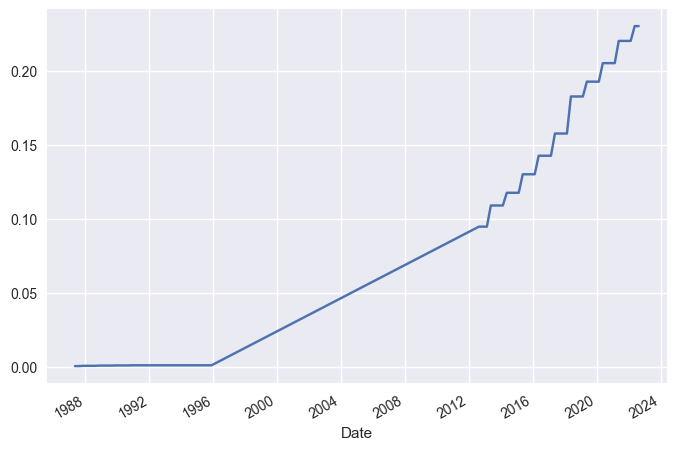

In [45]:
df.loc[df.Dividends != 0].Dividends.plot()
plt.show()

-> AAPL Dividend Policy: 
- historically __low-dividend__ stock (focus on growth) 
- Dividend Payouts __smoothed and steadily growing__ (highly predictable)
- __Avoiding Dividend Cuts__ in less profitable years (negative signal in the market)

## What´s the Adjusted Close Price?

"The Adjusted Close Price is the backward adjusted (reduced) Close Price (adjusted for Dividends)."   

In [ ]:
df

In [46]:
df2 = df[["Close", "Adj Close", "Dividends"]].copy()
df2

,Close,Adj Close,Dividends
Date,,,
1980-12-12,0.128348,0.100039,0.0
1980-12-15,0.121652,0.094820,0.0
1980-12-16,0.112723,0.087861,0.0
1980-12-17,0.115513,0.090035,0.0
1980-12-18,0.118862,0.092646,0.0
...,...,...,...
2022-10-17,142.410004,142.410004,0.0
2022-10-18,143.750000,143.750000,0.0
2022-10-19,143.860001,143.860001,0.0


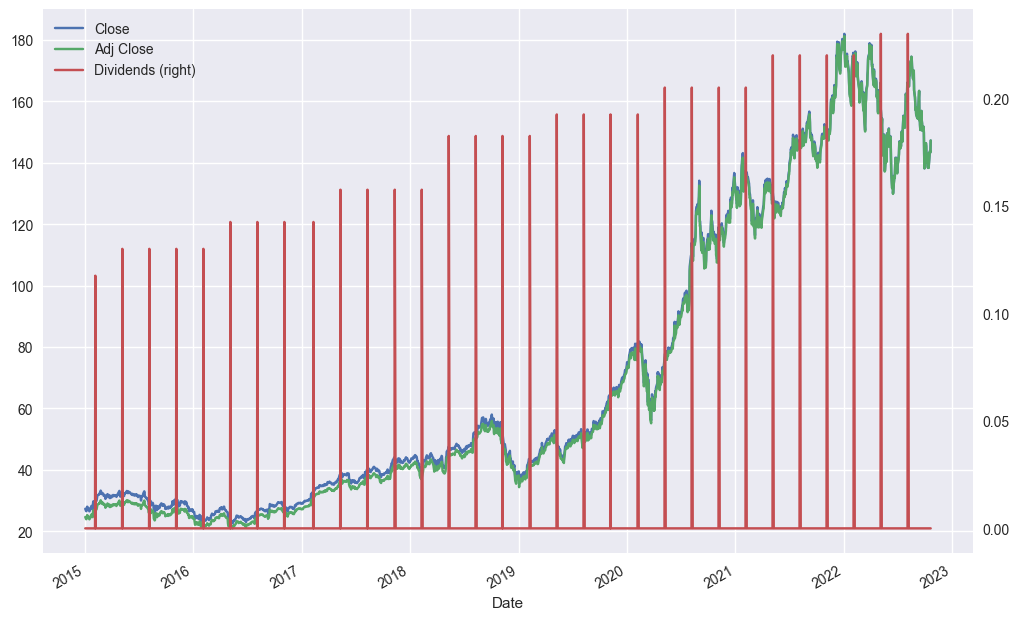

In [47]:
df2.loc["2015":].plot(figsize = (12, 8), secondary_y = "Dividends")
plt.show()

In [48]:
df2[df2.Dividends > 0]

,Close,Adj Close,Dividends
Date,,,
1987-05-11,0.343750,0.268340,0.000536
1987-08-10,0.430804,0.336732,0.000536
1987-11-17,0.312500,0.244794,0.000714
1988-02-12,0.366071,0.287323,0.000714
1988-05-16,0.368304,0.289648,0.000714
...,...,...,...
2021-08-06,146.139999,145.325668,0.220000
2021-11-05,151.279999,150.656570,0.220000
2022-02-04,172.389999,171.898315,0.220000


In [49]:
last_div = df2.loc["2022-08-01": "2022-08-5"].copy()
last_div

,Close,Adj Close,Dividends
Date,,,
2022-08-01,161.509995,161.285965,0.00
2022-08-02,160.009995,159.788040,0.00
2022-08-03,166.130005,165.899567,0.00
2022-08-04,165.809998,165.580002,0.00
2022-08-05,165.350006,165.350006,0.23


In [50]:
last_div.Close - last_div["Adj Close"]

Date
2022-08-01    0.224030
2022-08-02    0.221954
2022-08-03    0.230438
2022-08-04    0.229996
2022-08-05    0.000000
dtype: float64

https://in.help.yahoo.com/kb/adjusted-close-sln28256.html

In [51]:
multiplier = (1 - 0.23/165.809998)
multiplier

0.9986128701358528

In [52]:
last_div

,Close,Adj Close,Dividends
Date,,,
2022-08-01,161.509995,161.285965,0.00
2022-08-02,160.009995,159.788040,0.00
2022-08-03,166.130005,165.899567,0.00
2022-08-04,165.809998,165.580002,0.00
2022-08-05,165.350006,165.350006,0.23


In [53]:
last_div["Adj Close calc"] = last_div.Close * multiplier
last_div

,Close,Adj Close,Dividends,Adj Close calc
Date,,,,
2022-08-01,161.509995,161.285965,0.00,161.285959
2022-08-02,160.009995,159.788040,0.00,159.788040
2022-08-03,166.130005,165.899567,0.00,165.899561
2022-08-04,165.809998,165.580002,0.00,165.579998
2022-08-05,165.350006,165.350006,0.23,165.120644


In [54]:
df["Adj Close"] / df["Close"] # total multiplier (all dividends)

Date
1980-12-12    0.779439
1980-12-15    0.779440
1980-12-16    0.779439
1980-12-17    0.779440
1980-12-18    0.779439
                ...   
2022-10-17    1.000000
2022-10-18    1.000000
2022-10-19    1.000000
2022-10-20    1.000000
2022-10-21    1.000000
Length: 10555, dtype: float64

In [ ]:
df

__Interpretations:__
- Borrowing parts (e.g. 22%) of initial stock purchase price in 1980 and pay back borrowed amounts with Dividends. -or-
- Reinvesting Dividends and buying more shares with Dividends

__Benefits:__
- good approximation for a Stock´s __Total Return__ (Price Return + Dividend Yield)
- allows __Performance Comparison__ across stocks with different Payout Policies

## Stock Splits

In [ ]:
df

All Prices (OHLC, Adj Close) and Dividends are __backward adjusted__ (reduced) for Stock Splits. 

-> This __makes perfectly sense__ and you should not question it (unless you are interested in historical observable prices)!

In [55]:
splits = df.loc[df["Stock Splits"] > 0]
splits

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1987-06-16,0.370536,0.372768,0.339286,0.370536,0.289250,342720000,0.0,2.0
2000-06-21,0.901786,1.016741,0.898438,0.993304,0.848115,490000000,0.0,2.0
2005-02-28,1.595714,1.612143,1.570000,1.602143,1.367960,651610400,0.0,2.0
2014-06-09,23.174999,23.469999,22.937500,23.424999,20.925592,301660000,0.0,7.0
2020-08-31,127.580002,131.000000,126.000000,129.039993,127.500870,225702700,0.0,4.0


__Stock Split__: allows a company to break (split) each share into multiple shares __without affecting its market capitalization (total value of all its shares) or each investor's stake__ in the company. Motivation: reduce price per share and increase granularity.

__Example Stock Split 4:1__ -> Receive 4 new shares for 1 old share. Share Price immediately drops to 1/4 (no value effect)

On Yahoo Finance, Prices & Dividends are backward adjusted for Stock Splits. 

Price on 2020-08-31 __after Split__:

In [56]:
splits.loc["2020-08-31", "Close"] 

np.float64(129.0399932861328)

Price on 2020-08-31 __before Split__:

In [57]:
splits.loc["2020-08-31", "Close"] * splits.loc["2020-08-31", "Stock Splits"]

np.float64(516.1599731445312)

__-> 4 * 129 == 1 * 516__

__Calculate the unadjusted (observable) prices__

In [58]:
df["Stock Splits"].replace(to_replace = 0, value = 1, inplace = True) # 1:1 on all other days
df

C:\Users\priya\AppData\Local\Temp\ipykernel_16104\4182000373.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Stock Splits"].replace(to_replace = 0, value = 1, inplace = True) # 1:1 on all other days


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100039,469033600,0.0,1.0
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094820,175884800,0.0,1.0
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087861,105728000,0.0,1.0
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090035,86441600,0.0,1.0
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092646,73449600,0.0,1.0
...,...,...,...,...,...,...,...,...
2022-10-17,141.070007,142.899994,140.270004,142.410004,142.410004,85250900,0.0,1.0
2022-10-18,145.490005,146.699997,140.610001,143.750000,143.750000,99136600,0.0,1.0
2022-10-19,141.690002,144.949997,141.500000,143.860001,143.860001,61758300,0.0,1.0


In [59]:
df["Multiplier"] = df.sort_index(ascending = False)["Stock Splits"].cumprod() # cumulative multipier
df

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Multiplier
Date,,,,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100039,469033600,0.0,1.0,224.0
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094820,175884800,0.0,1.0,224.0
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087861,105728000,0.0,1.0,224.0
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090035,86441600,0.0,1.0,224.0
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092646,73449600,0.0,1.0,224.0
...,...,...,...,...,...,...,...,...,...
2022-10-17,141.070007,142.899994,140.270004,142.410004,142.410004,85250900,0.0,1.0,1.0
2022-10-18,145.490005,146.699997,140.610001,143.750000,143.750000,99136600,0.0,1.0,1.0
2022-10-19,141.690002,144.949997,141.500000,143.860001,143.860001,61758300,0.0,1.0,1.0


In [60]:
df["Close_unadj"] = df["Close"] * df.Multiplier # observable close price
df

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Multiplier,Close_unadj
Date,,,,,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100039,469033600,0.0,1.0,224.0,28.749950
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094820,175884800,0.0,1.0,224.0,27.250048
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087861,105728000,0.0,1.0,224.0,25.249952
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090035,86441600,0.0,1.0,224.0,25.874911
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092646,73449600,0.0,1.0,224.0,26.625089
...,...,...,...,...,...,...,...,...,...,...
2022-10-17,141.070007,142.899994,140.270004,142.410004,142.410004,85250900,0.0,1.0,1.0,142.410004
2022-10-18,145.490005,146.699997,140.610001,143.750000,143.750000,99136600,0.0,1.0,1.0,143.750000
2022-10-19,141.690002,144.949997,141.500000,143.860001,143.860001,61758300,0.0,1.0,1.0,143.860001


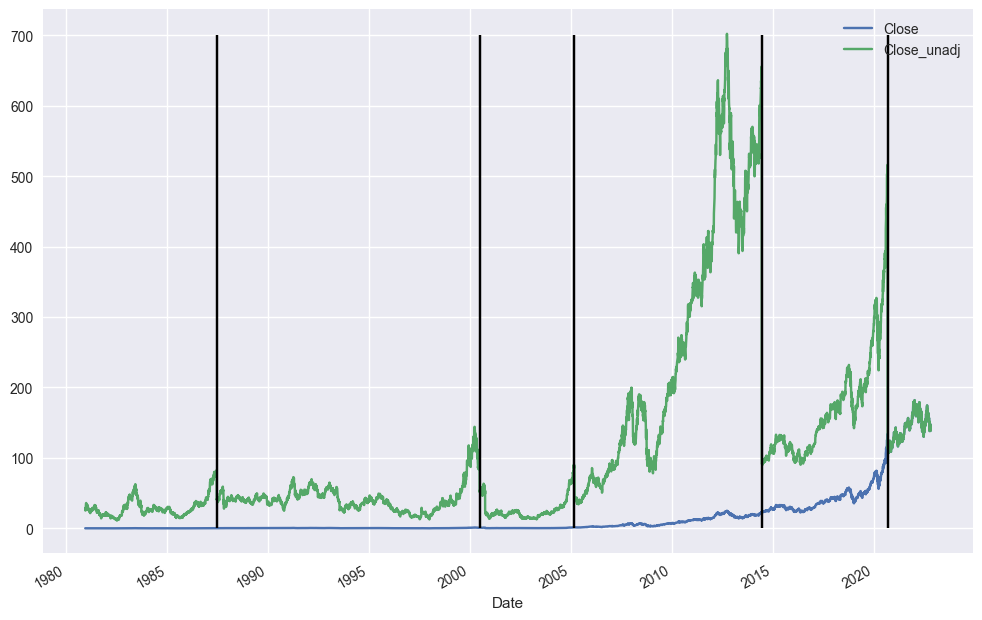

In [61]:
df[["Close", "Close_unadj"]].plot(figsize = (12 ,8))
plt.vlines(splits.index, 0, 700, color = "black")
plt.show()

__-> (backward adjusted) prices correctly reflect true price performance. They ignore price drops caused by stock splits!__

__unadjusted Dividends__

In [62]:
df["div_unadj"] = df["Dividends"] * df.Multiplier

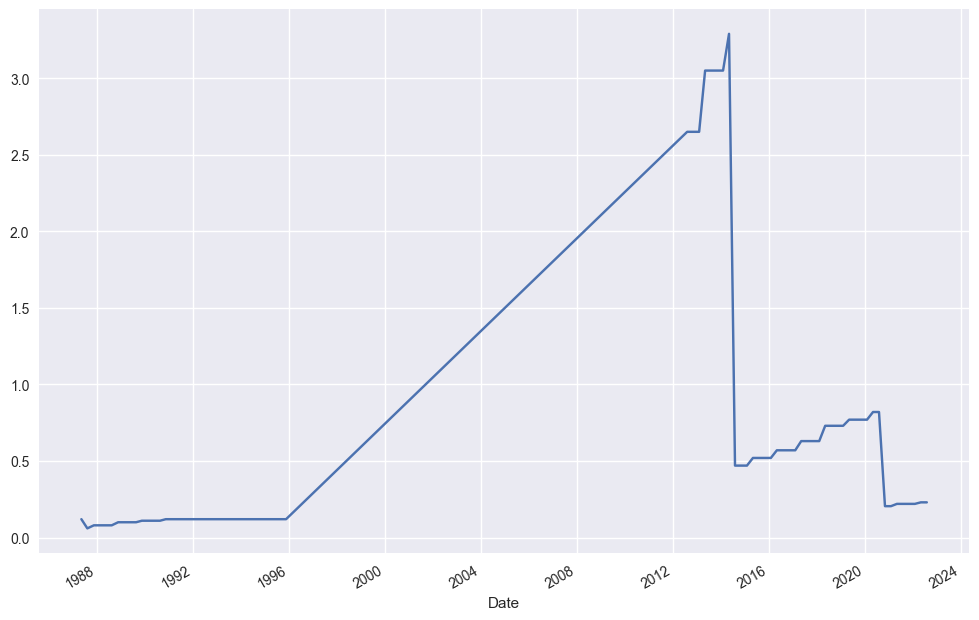

In [63]:
df.loc[df.div_unadj != 0].div_unadj.plot(figsize = (12, 8))
plt.show()

__unadjusted Trading Volume (number of shares)__

In [64]:
df["Volume_unadj"] = df["Volume"] / df.Multiplier

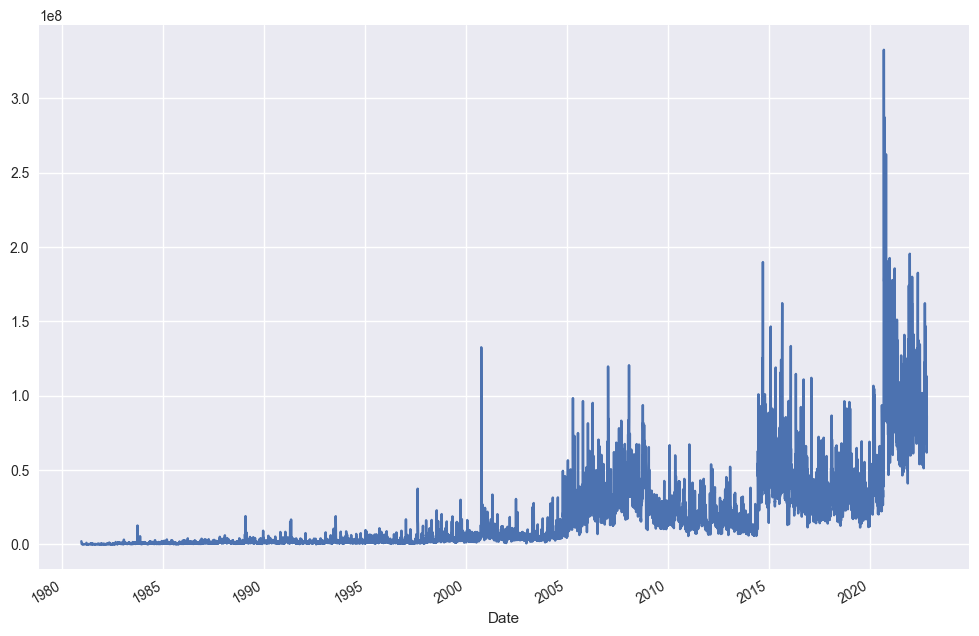

In [65]:
df["Volume_unadj"].plot(figsize = (12, 8))
plt.show()

## Stocks from other Countries / Exchanges 

In [ ]:
yf.download(tickers = "AAPL") # US Ticker (no suffix)

In [ ]:
#yf.download(tickers = "RELIANCE") # Indian Ticker (no suffix)

__Exchange List:__ 

https://help.yahoo.com/kb/SLN2310.html

In [ ]:
yf.download(tickers = "RELIANCE.NS") # Indian Ticker

In [ ]:
yf.download(tickers = "LHA.DE") # German Ticker (Deutsche Boerse XETRA)

In [ ]:
yf.download(tickers = "LHA.F") # German Ticker (Frankfurt Stock Exchange)

## Multiple Tickers

In [66]:
df = yf.download(tickers = ["AAPL", "MSFT"]) # multiple tickers
df

[*********************100%***********************]  2 of 2 completed


Price            Close                    High                     Low  \
Ticker            AAPL        MSFT        AAPL        MSFT        AAPL   
Date                                                                     
2026-02-03  269.228088  410.273560  271.625839  421.088870  267.359811   
2026-02-04  276.231506  413.246796  278.689229  418.844006  272.035451   
2026-02-05  275.652069  392.773529  279.238709  407.370187  272.974582   
2026-02-06  277.859985  400.226501  280.647386  400.875015  276.671095   
2026-02-09  274.619995  412.658142  278.200012  413.945213  271.700012   
2026-02-10  273.679993  412.328857  275.369995  422.715155  272.940002   
2026-02-11  275.500000  403.449127  280.179993  415.511591  274.450012   
2026-02-12  261.730011  400.924896  275.720001  405.274983  260.179993   
2026-02-13  255.779999  400.406097  262.230011  404.616489  255.449997   
2026-02-17  263.880005  395.956238  266.290009  399.607907  255.539993   
2026-02-18  264.350006  398.690002  266.820007  401.643253  262.450012   
2026-02-19  260.579987  398.459991  264.480011  404.429993  260.049988   
2026-02-20  264.579987  397.230011  264.750000  400.119995  258.160004   
2026-02-23  266.179993  384.470001  269.429993  395.359985  263.380005   
2026-02-24  272.140015  389.000000  274.890015  389.359985  267.709991   
2026-02-25  274.230011  400.600006  274.940002  401.470001  271.049988   
2026-02-26  272.950012  401.720001  276.109985  407.489990  270.799988   
2026-02-27  264.179993  392.739990  272.809998  396.820007  262.890015   
2026-03-02  264.720001  398.549988  266.529999  401.190002  260.200012   

Price                         Open                Volume            
Ticker            MSFT        AAPL        MSFT      AAPL      MSFT  
Date                                                                
2026-02-03  407.629600  268.948351  421.048983  64394700  61424100  
2026-02-04  408.308056  272.035451  410.064058  90545700  45012400  
2026-02-05  391.426597  277.869995  406.512160  52977400  66289200  
2026-02-06  392.025220  276.860920  398.260987  50453400  53515300  
2026-02-09  399.957120  277.910004  403.928068  44623400  45480500  
2026-02-10  411.760179  274.890015  418.664403  34376900  44857900  
2026-02-11  400.096794  274.700012  415.232230  51931300  42491000  
2026-02-12  397.103632  275.589996  404.077704  81077200  40802400  
2026-02-13  397.143525  262.010010  403.528974  56290700  34091600  
2026-02-17  393.631557  258.049988  398.310879  58469100  32078800  
2026-02-18  395.417473  263.600006  397.223349  34203300  23223400  
2026-02-19  396.670013  262.600006  400.690002  30845300  28234000  
2026-02-20  395.160004  258.970001  396.109985  42070500  34015200  
2026-02-23  383.100006  263.489990  395.000000  37308200  43238300  
2026-02-24  381.709991  267.859985  384.140015  47014600  33884700  
2026-02-25  390.160004  271.779999  390.529999  33714300  43625500  
2026-02-26  398.739990  274.950012  404.709991  32345100  34405900  
2026-02-27  389.880005  272.809998  390.880005  72366500  51367200  
2026-03-02  390.630005  262.410004  392.859985  41780100  35405100

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19 entries, 2026-02-03 to 2026-03-02
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   19 non-null     float64
 1   (Close, MSFT)   19 non-null     float64
 2   (High, AAPL)    19 non-null     float64
 3   (High, MSFT)    19 non-null     float64
 4   (Low, AAPL)     19 non-null     float64
 5   (Low, MSFT)     19 non-null     float64
 6   (Open, AAPL)    19 non-null     float64
 7   (Open, MSFT)    19 non-null     float64
 8   (Volume, AAPL)  19 non-null     int64  
 9   (Volume, MSFT)  19 non-null     int64  
dtypes: float64(8), int64(2)
memory usage: 1.6 KB


In [68]:
df.columns

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'MSFT'),
            (  'High', 'AAPL'),
            (  'High', 'MSFT'),
            (   'Low', 'AAPL'),
            (   'Low', 'MSFT'),
            (  'Open', 'AAPL'),
            (  'Open', 'MSFT'),
            ('Volume', 'AAPL'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])

In [69]:
df.Close # outer index level

Ticker,AAPL,MSFT
Date,,
2026-02-03,269.228088,410.273560
2026-02-04,276.231506,413.246796
2026-02-05,275.652069,392.773529
2026-02-06,277.859985,400.226501
2026-02-09,274.619995,412.658142
2026-02-10,273.679993,412.328857
2026-02-11,275.500000,403.449127
2026-02-12,261.730011,400.924896
2026-02-13,255.779999,400.406097


In [70]:
df.loc[:, ("Close", "MSFT")] # one specific column

Date
2026-02-03    410.273560
2026-02-04    413.246796
2026-02-05    392.773529
2026-02-06    400.226501
2026-02-09    412.658142
2026-02-10    412.328857
2026-02-11    403.449127
2026-02-12    400.924896
2026-02-13    400.406097
2026-02-17    395.956238
2026-02-18    398.690002
2026-02-19    398.459991
2026-02-20    397.230011
2026-02-23    384.470001
2026-02-24    389.000000
2026-02-25    400.600006
2026-02-26    401.720001
2026-02-27    392.739990
2026-03-02    398.549988
Name: (Close, MSFT), dtype: float64

In [71]:
df.Close.MSFT # one specific column

Date
2026-02-03    410.273560
2026-02-04    413.246796
2026-02-05    392.773529
2026-02-06    400.226501
2026-02-09    412.658142
2026-02-10    412.328857
2026-02-11    403.449127
2026-02-12    400.924896
2026-02-13    400.406097
2026-02-17    395.956238
2026-02-18    398.690002
2026-02-19    398.459991
2026-02-20    397.230011
2026-02-23    384.470001
2026-02-24    389.000000
2026-02-25    400.600006
2026-02-26    401.720001
2026-02-27    392.739990
2026-03-02    398.549988
Name: MSFT, dtype: float64

In [ ]:
df.loc[:, (slice(None), slice("AAPL"))] # inner index level

In [ ]:
df = df.swaplevel(axis = "columns").sort_index(axis = "columns")
df

In [ ]:
df.AAPL

In [ ]:
df = yf.download(tickers = ["LHA.F", "LHA.DE"]).Close
df

In [ ]:
#df.LHA.F # incorrect

In [ ]:
df["LHA.F"]

In [ ]:
df.columns = ["LHA_DE", "LHA_F"]

In [ ]:
df

In [ ]:
df.LHA_F

## Saving and Loading Data (Local Files)

In [72]:
import yfinance as yf
import pandas as pd

In [73]:
symbol = "AAPL"

In [74]:
df = yf.download(symbol, multi_level_index = False) # use multi_level_index: this simplifies the next steps
df

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2026-02-03,269.228088,271.625839,267.359811,268.948351,64394700
2026-02-04,276.231506,278.689229,272.035451,272.035451,90545700
2026-02-05,275.652069,279.238709,272.974582,277.869995,52977400
2026-02-06,277.859985,280.647386,276.671095,276.860920,50453400
2026-02-09,274.619995,278.200012,271.700012,277.910004,44623400
2026-02-10,273.679993,275.369995,272.940002,274.890015,34376900
2026-02-11,275.500000,280.179993,274.450012,274.700012,51931300
2026-02-12,261.730011,275.720001,260.179993,275.589996,81077200
2026-02-13,255.779999,262.230011,255.449997,262.010010,56290700


In [82]:
df.to_csv(path_or_buf = "apple_new.csv") # writing to local csv

In [80]:
df2 = pd.read_csv("apple_new.csv", index_col="Date", parse_dates= ["Date"]) # loading from local csv
df2

,Close,High,Low,Open,Volume
Date,,,,,
2026-02-03,269.228088,271.625839,267.359811,268.948351,64394700
2026-02-04,276.231506,278.689229,272.035451,272.035451,90545700
2026-02-05,275.652069,279.238709,272.974582,277.869995,52977400
2026-02-06,277.859985,280.647386,276.671095,276.860920,50453400
2026-02-09,274.619995,278.200012,271.700012,277.910004,44623400
2026-02-10,273.679993,275.369995,272.940002,274.890015,34376900
2026-02-11,275.500000,280.179993,274.450012,274.700012,51931300
2026-02-12,261.730011,275.720001,260.179993,275.589996,81077200
2026-02-13,255.779999,262.230011,255.449997,262.010010,56290700


In [ ]:
df2.info()

__multiple symbols__

In [83]:
symbols = ["AAPL", "MSFT"]

In [84]:
df = yf.download(symbols)
df

[*********************100%***********************]  2 of 2 completed


Price            Close                    High                     Low  \
Ticker            AAPL        MSFT        AAPL        MSFT        AAPL   
Date                                                                     
2026-02-03  269.228088  410.273560  271.625839  421.088870  267.359811   
2026-02-04  276.231506  413.246796  278.689229  418.844006  272.035451   
2026-02-05  275.652069  392.773529  279.238709  407.370187  272.974582   
2026-02-06  277.859985  400.226501  280.647386  400.875015  276.671095   
2026-02-09  274.619995  412.658142  278.200012  413.945213  271.700012   
2026-02-10  273.679993  412.328857  275.369995  422.715155  272.940002   
2026-02-11  275.500000  403.449127  280.179993  415.511591  274.450012   
2026-02-12  261.730011  400.924896  275.720001  405.274983  260.179993   
2026-02-13  255.779999  400.406097  262.230011  404.616489  255.449997   
2026-02-17  263.880005  395.956238  266.290009  399.607907  255.539993   
2026-02-18  264.350006  398.690002  266.820007  401.643253  262.450012   
2026-02-19  260.579987  398.459991  264.480011  404.429993  260.049988   
2026-02-20  264.579987  397.230011  264.750000  400.119995  258.160004   
2026-02-23  266.179993  384.470001  269.429993  395.359985  263.380005   
2026-02-24  272.140015  389.000000  274.890015  389.359985  267.709991   
2026-02-25  274.230011  400.600006  274.940002  401.470001  271.049988   
2026-02-26  272.950012  401.720001  276.109985  407.489990  270.799988   
2026-02-27  264.179993  392.739990  272.809998  396.820007  262.890015   
2026-03-02  264.720001  398.549988  266.529999  401.190002  260.200012   

Price                         Open                Volume            
Ticker            MSFT        AAPL        MSFT      AAPL      MSFT  
Date                                                                
2026-02-03  407.629600  268.948351  421.048983  64394700  61424100  
2026-02-04  408.308056  272.035451  410.064058  90545700  45012400  
2026-02-05  391.426597  277.869995  406.512160  52977400  66289200  
2026-02-06  392.025220  276.860920  398.260987  50453400  53515300  
2026-02-09  399.957120  277.910004  403.928068  44623400  45480500  
2026-02-10  411.760179  274.890015  418.664403  34376900  44857900  
2026-02-11  400.096794  274.700012  415.232230  51931300  42491000  
2026-02-12  397.103632  275.589996  404.077704  81077200  40802400  
2026-02-13  397.143525  262.010010  403.528974  56290700  34091600  
2026-02-17  393.631557  258.049988  398.310879  58469100  32078800  
2026-02-18  395.417473  263.600006  397.223349  34203300  23223400  
2026-02-19  396.670013  262.600006  400.690002  30845300  28234000  
2026-02-20  395.160004  258.970001  396.109985  42070500  34015200  
2026-02-23  383.100006  263.489990  395.000000  37308200  43238300  
2026-02-24  381.709991  267.859985  384.140015  47014600  33884700  
2026-02-25  390.160004  271.779999  390.529999  33714300  43625500  
2026-02-26  398.739990  274.950012  404.709991  32345100  34405900  
2026-02-27  389.880005  272.809998  390.880005  72366500  51367200  
2026-03-02  390.630005  262.410004  392.859985  41780100  35405100

In [85]:
df.to_csv(path_or_buf = "two_stocks.csv") # writing to local csv

In [87]:
df2 = pd.read_csv("two_stocks.csv", header = [0, 1], index_col = [0], parse_dates = [0]) # loading from local csv
df2

Price            Close                    High                     Low  \
Ticker            AAPL        MSFT        AAPL        MSFT        AAPL   
Date                                                                     
2026-02-03  269.228088  410.273560  271.625839  421.088870  267.359811   
2026-02-04  276.231506  413.246796  278.689229  418.844006  272.035451   
2026-02-05  275.652069  392.773529  279.238709  407.370187  272.974582   
2026-02-06  277.859985  400.226501  280.647386  400.875015  276.671095   
2026-02-09  274.619995  412.658142  278.200012  413.945213  271.700012   
2026-02-10  273.679993  412.328857  275.369995  422.715155  272.940002   
2026-02-11  275.500000  403.449127  280.179993  415.511591  274.450012   
2026-02-12  261.730011  400.924896  275.720001  405.274983  260.179993   
2026-02-13  255.779999  400.406097  262.230011  404.616489  255.449997   
2026-02-17  263.880005  395.956238  266.290009  399.607907  255.539993   
2026-02-18  264.350006  398.690002  266.820007  401.643253  262.450012   
2026-02-19  260.579987  398.459991  264.480011  404.429993  260.049988   
2026-02-20  264.579987  397.230011  264.750000  400.119995  258.160004   
2026-02-23  266.179993  384.470001  269.429993  395.359985  263.380005   
2026-02-24  272.140015  389.000000  274.890015  389.359985  267.709991   
2026-02-25  274.230011  400.600006  274.940002  401.470001  271.049988   
2026-02-26  272.950012  401.720001  276.109985  407.489990  270.799988   
2026-02-27  264.179993  392.739990  272.809998  396.820007  262.890015   
2026-03-02  264.720001  398.549988  266.529999  401.190002  260.200012   

Price                         Open                Volume            
Ticker            MSFT        AAPL        MSFT      AAPL      MSFT  
Date                                                                
2026-02-03  407.629600  268.948351  421.048983  64394700  61424100  
2026-02-04  408.308056  272.035451  410.064058  90545700  45012400  
2026-02-05  391.426597  277.869995  406.512160  52977400  66289200  
2026-02-06  392.025220  276.860920  398.260987  50453400  53515300  
2026-02-09  399.957120  277.910004  403.928068  44623400  45480500  
2026-02-10  411.760179  274.890015  418.664403  34376900  44857900  
2026-02-11  400.096794  274.700012  415.232230  51931300  42491000  
2026-02-12  397.103632  275.589996  404.077704  81077200  40802400  
2026-02-13  397.143525  262.010010  403.528974  56290700  34091600  
2026-02-17  393.631557  258.049988  398.310879  58469100  32078800  
2026-02-18  395.417473  263.600006  397.223349  34203300  23223400  
2026-02-19  396.670013  262.600006  400.690002  30845300  28234000  
2026-02-20  395.160004  258.970001  396.109985  42070500  34015200  
2026-02-23  383.100006  263.489990  395.000000  37308200  43238300  
2026-02-24  381.709991  267.859985  384.140015  47014600  33884700  
2026-02-25  390.160004  271.779999  390.529999  33714300  43625500  
2026-02-26  398.739990  274.950012  404.709991  32345100  34405900  
2026-02-27  389.880005  272.809998  390.880005  72366500  51367200  
2026-03-02  390.630005  262.410004  392.859985  41780100  35405100

In [88]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19 entries, 2026-02-03 to 2026-03-02
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   19 non-null     float64
 1   (Close, MSFT)   19 non-null     float64
 2   (High, AAPL)    19 non-null     float64
 3   (High, MSFT)    19 non-null     float64
 4   (Low, AAPL)     19 non-null     float64
 5   (Low, MSFT)     19 non-null     float64
 6   (Open, AAPL)    19 non-null     float64
 7   (Open, MSFT)    19 non-null     float64
 8   (Volume, AAPL)  19 non-null     int64  
 9   (Volume, MSFT)  19 non-null     int64  
dtypes: float64(8), int64(2)
memory usage: 1.6 KB


## Coding Challenge

1. Load historical Prices, Volume and Dividends for the stocks "JNJ" (__Johnson & Johnson__) and "TSLA" (__Tesla__)

2. Analyze and compare Dividends, Stock Price Increase and Dividend Policy

3. Which stock is the high-dividend stock?

## --------------- Solution --------------------------

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [ ]:
symbols = ["JNJ", "TSLA"]

In [ ]:
df = yf.download(symbols, actions = True)
df

In [ ]:
df.Close.plot(figsize = (12, 8))
plt.show()

In [ ]:
df = df.swaplevel(axis = "columns").sort_index(axis = "columns")
df

In [ ]:
jnj = df.JNJ
jnj

In [ ]:
jnj[["Close", "Adj Close"]].plot(figsize = (12, 8))
plt.show()

__Dividends__

In [ ]:
jnj.Dividends.sum()

__Price Increase__

In [ ]:
jnj.Close.iloc[-1] - jnj.Close.iloc[0] # from Pandas v. 2.0 use iloc!

__Dividend Policy__

In [ ]:
jnj.loc[jnj.Dividends != 0].Dividends.plot()
plt.show()

In [ ]:
tsla = df.TSLA.dropna()
tsla

In [ ]:
tsla[["Close", "Adj Close"]].plot(figsize = (12, 8))
plt.show()

__Dividends__

In [ ]:
tsla.Dividends.sum()

__Price Increase__

In [ ]:
tsla.Close.iloc[-1] - tsla.Close.iloc[0]

__Dividend Policy__

In [ ]:
tsla.loc[tsla.Dividends != 0].Dividends.plot()
plt.show()

__-> JNJ is the high-dividend stock__